In [ ]:
import cv2
import numpy as np

from PIL import Image
from IPython.display import display

import skimage as ski


def show(img_rgb, scale_factor=0.25):
    # if greyscale, convert to RGB
    if len(img_rgb.shape) == 2:
        img_rgb = cv2.cvtColor(img_rgb, cv2.COLOR_GRAY2RGB)
    img_rgb = cv2.cvtColor(img_rgb, cv2.COLOR_BGR2RGB)
    scaled_img = cv2.resize(img_rgb, (img_rgb.shape[1] // int(1/scale_factor), img_rgb.shape[0] // int(1/scale_factor)))
    display(Image.fromarray(scaled_img))
    return

video_source = r"uploads\IMG_1759.MOV"  # Change this to your video file path or camera index

cap = cv2.VideoCapture(video_source)
_ret, cap_1 = cap.read()  # Read the first frame to check if the video is valid

# get frame number 32
cap.set(cv2.CAP_PROP_POS_FRAMES, 32)
_ret, cap_32 = cap.read()
# cap_32 = cap_32[cap_32.shape[0]//4:cap_32.shape[0], :]  # crop to bottom 3/4ths
# cap_32 = cv2.imread(r"uploads\frames\frame_0011.png")  # for testing purposes, use a saved frame instead of the video frame

show(cap_1)
show(cap_32)
print(f"Resolution: {cap_1.shape}, FPS: {cap.get(cv2.CAP_PROP_FPS)}, Total Frames: {cap.get(cv2.CAP_PROP_FRAME_COUNT)}, duration: {cap.get(cv2.CAP_PROP_FRAME_COUNT) / cap.get(cv2.CAP_PROP_FPS)} seconds")

Starting the idolating sclera stuff

In [ ]:
import numpy as np

# cap_32_blur = cv2.blur(cap_32, (51, 51))
aspect_ratio = cap_32.shape[1] / cap_32.shape[0]
new_w = 500
if new_w > cap_32.shape[1]:
    new_w = int(cap_32.shape[1] * .25)
new_h = int(new_w / aspect_ratio)

cap_32_lowRes = cv2.resize(cap_32, (new_w, new_h), interpolation=cv2.INTER_AREA)
# cap_32_lowRes = cap_32_lowRes[new_h//4:new_h, :]  # crop to bottom 3/4ths
show(cap_32_lowRes)

In [ ]:
cap_32_hsv = cv2.cvtColor(cap_32_lowRes, cv2.COLOR_BGR2HSV)

thresh_hsv = cv2.inRange(cap_32_hsv, (0, 1, 180), (180, 35, 255))
opened_hsv = cv2.morphologyEx(thresh_hsv, cv2.MORPH_OPEN, np.ones((5,5), np.uint8))
close_hsv = cv2.morphologyEx(opened_hsv, cv2.MORPH_CLOSE, np.ones((11,11), np.uint8))
larg_Contour, _ = cv2.findContours(close_hsv, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
largest_contour = max(larg_Contour, key=cv2.contourArea) if larg_Contour else None
peri = cv2.arcLength(largest_contour, True)
simplified_contour = cv2.approxPolyDP(largest_contour, epsilon=0.015 * peri, closed=True)
#  get the corresponding mask of the largest contour
mask = np.zeros_like(close_hsv)
mask = cv2.drawContours(mask, [simplified_contour], -1, 255, thickness=cv2.FILLED)
    
show(thresh_hsv)
show(opened_hsv)
show(close_hsv)
show(mask)


In [ ]:

# Take the contour coords and multiply by a transformation matrix to get the corresponding coords in the original image, then draw the contour on the original image
M = np.array([[cap_32.shape[1] / new_w, 0, 0],
              [0, cap_32.shape[0] / new_h, 25],
              [0, 0, 1]])

# make the contour coords homogeneous
# take out one of the wrappers for the contour coords
homogeneous_coords = np.hstack([largest_contour.reshape(-1, 2), np.ones((largest_contour.shape[0], 1))])
print(f"homogeneous coords shape: {homogeneous_coords.shape} and values: {homogeneous_coords[:5]}")
transformed_coords = (M @ homogeneous_coords.T).T[:, :2].astype(int)

# draw the contour on the original image
contour_img = cap_32.copy()
contour_zero = np.zeros_like(contour_img)
mask = cv2.drawContours(contour_zero, [transformed_coords], -1, 255, thickness=cv2.FILLED)
contour_img = cap_32 * mask.astype(bool)
print(f"contour_img shape: {contour_img.shape}")

#debugging code to look for good pixels
nonzero_mask = np.any(contour_img != 0, axis=2)  # shape: (1080, 1280)
rows, cols = np.where(nonzero_mask)

print(f"contour_img pixel at ({rows[0:5]}, {cols[0:5]}): {contour_img[rows[0:5], cols[0:5]]}")
# print(f"contour_img values: {np.unique(contour_img)}") # use numpy to show me a pixel with values
print(f"mask shape: {mask.shape} cap_32.shape: {cap_32.shape}")
show(contour_img)


show(mask)


OK so that was all the sclera stuff, this going to optimizing the stabilization

In [1]:
#close the first video capture
# cap.close()
# cap.release()
def show(img_rgb, scale_factor=0.25):
    # if greyscale, convert to RGB
    if len(img_rgb.shape) == 2:
        img_rgb = cv2.cvtColor(img_rgb, cv2.COLOR_GRAY2RGB)
    img_rgb = cv2.cvtColor(img_rgb, cv2.COLOR_BGR2RGB)
    scaled_img = cv2.resize(img_rgb, (img_rgb.shape[1] // int(1/scale_factor), img_rgb.shape[0] // int(1/scale_factor)))
    display(Image.fromarray(scaled_img))
    return


import os
from CV_steps.sclera import sclera_pipeline
from PIL import Image


# cap = cv2.VideoCapture(video_source)
video_source = r"uploads\IMG_1759.MOV"  # Change this to your video file path or camera index

testing_out = os.path.join("output", "jupyter_test")
os.makedirs(testing_out, exist_ok=True)
print(f"Testing output directory: {testing_out}")

outlined_path = os.path.join(testing_out, "sclera_outline.mp4")
mask_path = os.path.join(testing_out, "sclera_mask.mp4")

# sclera_pipeline(str(video_source), outlined_path, mask_path, max_workers=8)

ModuleNotFoundError: No module named 'cv2'

In [ ]:
from CV_steps.stabilize import stabilize_video


stabilize_video(mask_path, os.path.join(testing_out, f"sclera_mask_stabilized.mp4"))

# try a bunch of different smoothing radius values and see how it looks
# for radius in [10, 20, 30, 50, 75, 100]:
#     stabilize_video(mask_path, os.path.join(testing_out, f"sclera_mask_stabilized_{radius}.mp4"), smoothing_radius=radius)
#     print(f"Stabilized video with radius {radius} saved to {os.path.join(testing_out, f'sclera_mask_stabilized_{radius}.mp4')}")

# Also test stabilizing then isolating the sclear

# stab_path = os.path.join(testing_out, f"video_stabilized.mp4")
# stabilize_video(video_source, stab_path, smoothing_radius=50)

# sclera_pipeline(stab_path, os.path.join(testing_out, f"video_stabilized_sclera_outline.mp4"), os.path.join(testing_out, f"video_stabilized_sclera_mask.mp4"), max_workers=8)

In [7]:
# Import numpy and OpenCV
import numpy as np
import cv2
 
# Read input video
cap = cv2.VideoCapture(mask_path)
 
# Get frame count
n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
 
# Get width and height of video stream
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
 
# Define the codec for output video
fourcc = cv2.VideoWriter_fourcc(*'MJPG')


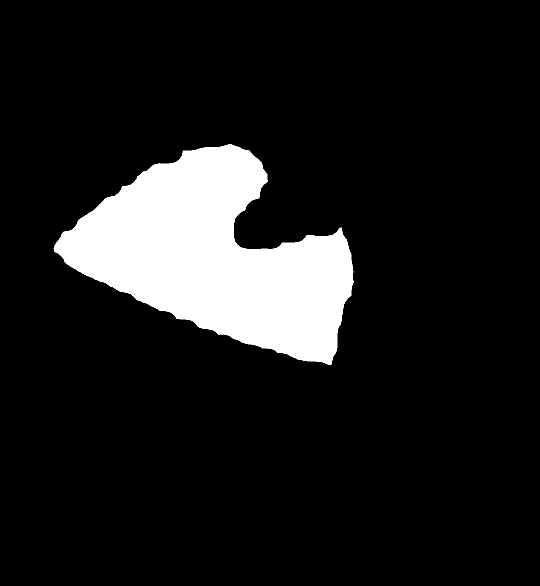

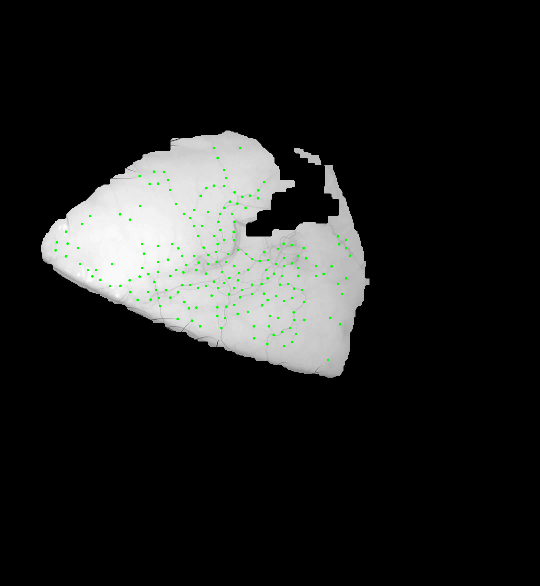

In [8]:
# Read first frame
_, prev = cap.read()
 
# Convert frame to grayscale
prev_gray = cv2.cvtColor(prev, cv2.COLOR_BGR2GRAY)

# show features detected in the first frame
# make a mask of all the current data and then erode it shrink it
mask = cv2.threshold(prev_gray, 1, 255, cv2.THRESH_BINARY)[1]
# somehow shrink the mask

# kernel = np.ones((5,5), np.uint8)
# mask = cv2.erode(mask, kernel, iterations=5)

dist = cv2.distanceTransform(mask, cv2.DIST_L2, 5) # calculate distance from edge for each pixel
mask = (dist > 50).astype(np.uint8) * 255  # keep only pixels >50px from any edge

show(mask)
features = cv2.goodFeaturesToTrack(prev_gray, maxCorners=200, qualityLevel=0.01, minDistance=30, blockSize=3, mask=mask)
features = np.intp(features)

featured_prev = cv2.cvtColor(prev_gray, cv2.COLOR_GRAY2BGR)
for feature in features:
    x, y = feature.ravel()
    cv2.circle(featured_prev, (x, y), 5, (0, 255, 0), -1)

show(featured_prev)



writer set up at output\jupyter_test\mask_stabilized_test.mp4 with resolution (2160, 2344) and FPS 24.0


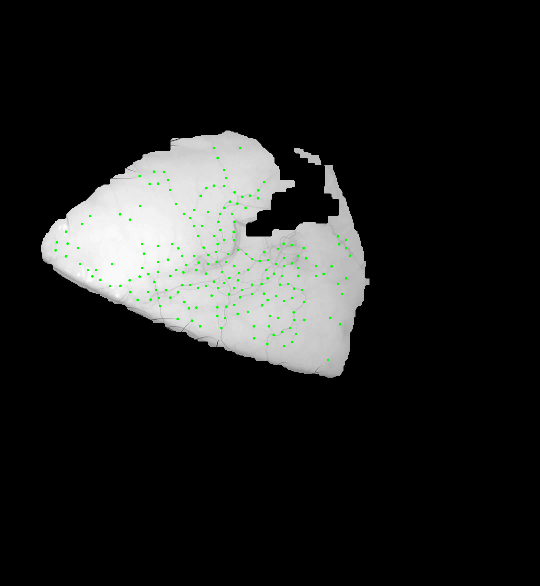

Stabilized video saved to output\jupyter_test\mask_stabilized_test.mp4


In [12]:
# Import numpy and OpenCV
import numpy as np
import cv2
 
# Read input video
cap = cv2.VideoCapture(mask_path)
 
# Get frame count
n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
 
# Get width and height of video stream
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
 
# Define the codec for output video
fourcc = cv2.VideoWriter_fourcc(*'MJPG')


# Set up output video
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out_path = os.path.join(testing_out, "mask_stabilized_test.mp4")
out_writer = cv2.VideoWriter(out_path, fourcc, cap.get(cv2.CAP_PROP_FPS), (w, h))
print(f"writer set up at {out_path} with resolution {(w, h)} and FPS {cap.get(cv2.CAP_PROP_FPS)}")

# Read first frame
_, prev = cap.read()
 
# Convert frame to grayscale
prev_gray = cv2.cvtColor(prev, cv2.COLOR_BGR2GRAY)

# show features detected in the first frame
# make a mask of all the current data and then erode it shrink it
mask = cv2.threshold(prev_gray, 1, 255, cv2.THRESH_BINARY)[1]
# somehow shrink the mask

# kernel = np.ones((5,5), np.uint8)
# mask = cv2.erode(mask, kernel, iterations=5)

dist = cv2.distanceTransform(mask, cv2.DIST_L2, 5) # calculate distance from edge for each pixel
mask = (dist > 50).astype(np.uint8) * 255  # keep only pixels >50px from any edge

# show(mask)
features = cv2.goodFeaturesToTrack(prev_gray, maxCorners=200, qualityLevel=0.01, minDistance=30, blockSize=3, mask=mask)
features = np.intp(features)

featured_prev = cv2.cvtColor(prev_gray, cv2.COLOR_GRAY2BGR)
for feature in features:
    x, y = feature.ravel()
    cv2.circle(featured_prev, (x, y), 5, (0, 255, 0), -1)

show(featured_prev)
# calculate the optical flow (i.e. track feature points)
for _ in range(1, n_frames):
    # Read next frame
    success, img = cap.read()
    if not success:
        print("No more frames to read or error reading frame.")
        break
 
    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
 
    # show features detected in the first frame
    # make a mask of all the current data and then erode it shrink it
    mask = cv2.threshold(prev_gray, 1, 255, cv2.THRESH_BINARY)[1]
    # somehow shrink the mask

    # kernel = np.ones((5,5), np.uint8)
    # mask = cv2.erode(mask, kernel, iterations=5)

    dist = cv2.distanceTransform(mask, cv2.DIST_L2, 5) # calculate distance from edge for each pixel
    mask = (dist > 50).astype(np.uint8) * 255  # keep only pixels >50px from any edge

    # show(mask)
    features = cv2.goodFeaturesToTrack(prev_gray, maxCorners=200, qualityLevel=0.01, minDistance=30, blockSize=3, mask=mask)
    features = np.intp(features)

    featured_prev = cv2.cvtColor(prev_gray, cv2.COLOR_GRAY2BGR)
    for feature in features:
        x, y = feature.ravel()
        cv2.circle(featured_prev, (x, y), 5, (0, 255, 0), -1)

    # show(featured_prev)
    # Ensure features are in the correct format (float32, shape (n, 1, 2))
    if features is not None and len(features) > 0:
        features = features.astype(np.float32)# Calculate optical flow
    
    old_features = features.copy()
    features, status, _ = cv2.calcOpticalFlowPyrLK(prev_gray, gray, features, None)

    good_new = features[status == 1]
    good_old = old_features[status == 1]  # ← now actually the old positions
 
    # Estimate transformation matrix using RANSAC
    if len(good_new) >= 4:  # Need at least 4 points to compute homography
        matrix, _ = cv2.findHomography(good_old, good_new, cv2.RANSAC, 5.0)
        if matrix is not None:
            # Warp the current frame to align with the previous frame
            stabilized_frame = cv2.warpPerspective(img, matrix, (w, h))
            out_writer.write(stabilized_frame)
        else:
            print("Homography could not be computed for this frame.")
            out_writer.write(img)  # Write original frame if homography fails
    else:
        print("Not enough good points to compute homography for this frame.")
        out_writer.write(img)  # Write original frame if not enough points
 
    # Update previous frame and previous points
    prev_gray = gray.copy()
    features = good_new.reshape(-1, 1, 2)

# Release video objects
cap.release()
out_writer.release()
print(f"Stabilized video saved to {out_path}")




In [ ]:
# 